## My Excersise Notes ##

This exercise is about drawing statistical distributions and save the images as PDFs. About fitting statistical distributions to a histogram. About, calculating probabilites from statistical distributions, and lastly, about learning how to generate random numbers from uniform statistical distributions.

### Loading in the required packages ###

In [4]:
import pandas as pd     # to import data into a dataframe
import numpy as np      # to generate sequences of numbers
import seaborn as sns   # to draw graphs and have them look nice
import statistics       # to calculate mean and SD

from scipy.stats import norm, expon ## To generate y-axis coordinates for 
## distributions

## Drawing a statistical distribution

In [5]:
## create an array of x-axis coordinates
x_axis = np.arange(start=-5,
                   stop=5.1,
                   step=0.1)

## print out the first 10 values
x_axis[:10]

array([-5. , -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1])

In [6]:
## create an array of y-axis coordinates that correspond to each value in the x_axis
## NOTE: 'loc' = location = mean. This is because the mean is also called
## a "location parameter" since the mean determines the location of the center,
## or highest point, of the distribution.

## Conversely, the 'scale' = SD. This is because the SD is also called a "scale parameter"
## This is because the SD scales the height of the distribution. The larger the SD
## the smaller the height.

y_axis = norm.pdf(x = x_axis,
                  loc = 0,
                  scale = 1)

## print out the first 10 values
y_axis[:10]

array([1.48671951e-06, 2.43896075e-06, 3.96129909e-06, 6.36982518e-06,
       1.01408521e-05, 1.59837411e-05, 2.49424713e-05, 3.85351967e-05,
       5.89430678e-05, 8.92616572e-05])

<Axes: >

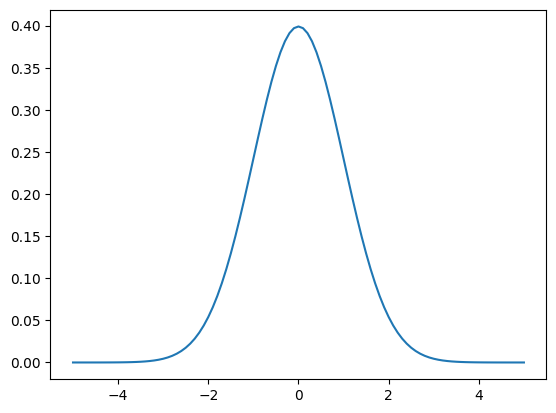

In [7]:
## Now that we have both x and y -axis coordingates for a normal distribution
# we can draw them with the sns.lineplot() function.
sns.lineplot(x = x_axis, y = y_axis)

Now, before we move on, I want to point out that we can change the color of
the distribution with `color`, and we can specify the thickness of the line 
with `linewidth`

<Axes: >

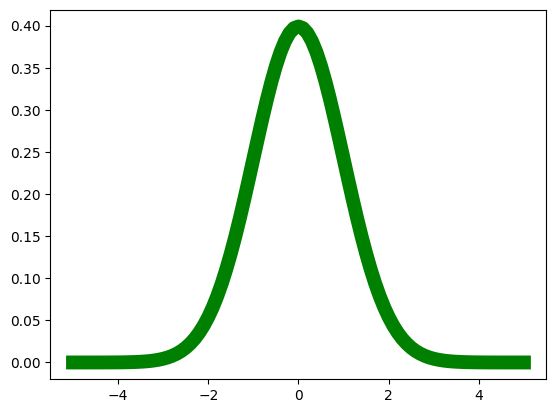

In [10]:
sns.lineplot(x = x_axis, y = y_axis,
             color='green',
             linewidth=10)

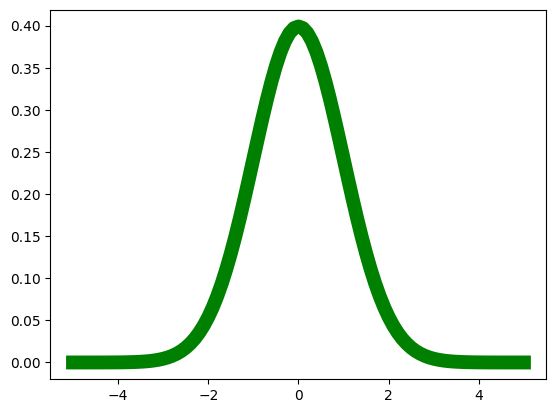

In [12]:
## To save the graph as a .pdf, use:
my_graph = sns.lineplot(x=x_axis, y=y_axis,
                        color='green',
                        linewidth=10)
## extract the figure from our graph...
fig = my_graph.get_figure()
## save the figure as a .pdf
fig.savefig('normal_curve.pdf')

Now that we know how to draw a graph of a normal curve and save it as a .pdf, let's learn how to do the same with the **Exponential Distribution**. The big difference between calling `norm.pdf()` and `expon.pdf()` is that instead of specifying the mean and SD, we just specify the mean. Also, in contrast to `norm.pdf()`, which uses the mean to define the location of the center of the distribution,`expon.pdf()`uses the mean to scale the height of the distribution.

In [14]:
## first, create the sequence x-axis values
x_exp = np.arange(start=0,
                   stop=10,
                   step=0.1)

## now define the mean value for our exponential distribution
exp_mean = 2

## Lastly, get the corresponding y-axis coordinates for each value in x_exp
y_exp = expon.pdf(x_exp, scale= exp_mean)

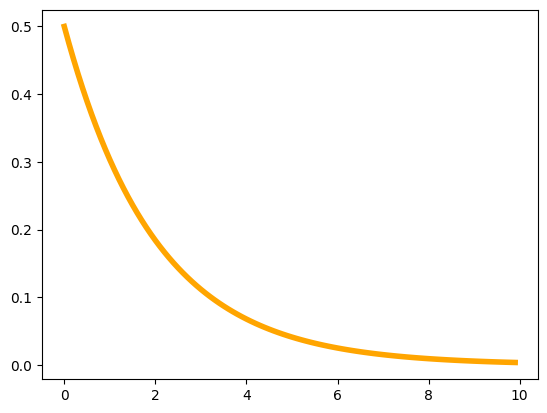

In [18]:
## Now that we have our exp_dist x and y-coordinates, 
# we can plot them, using 'sns.lineplot()'

my_exp_Graph = sns.lineplot(x=x_exp, y=y_exp,
                            color="orange",
                            linewidth=4)

In [22]:
# Saving the distribution as a .pdf

## Extract the figure from our graph...
fig = my_exp_Graph.get_figure()
## Save as .pdf
fig.savefig('exp_curve.pdf')

**NOTE:** If we want to draw a uniform distribution, we would do things similarly except we would use `uniform()` from `scipy.stats`. Likewise, we could import other distributions from `scipy.stats` and use them instead.

Now let´s learn how to fit a statistical distributions to a histogram.

In order to fit a stat-dist to a histogram, we have to import a tool and data for drawing the histogram with.

In [24]:
## First, use pd.read_csv() to read the data in "spend_n_save.txt"
spend_n_save_df = pd.read_csv("https://raw.githubusercontent.com/StatQuest/sigs/refs/heads/main/chapter_01/spend_n_save.txt", sep="\t")

## Rename num.apples to bum_apples so it's easier to access the values
spend_n_save_df.rename(columns={'num.apples': 'num_apples'}, inplace=True)

## Verify that read_csv() was successful by printing out the first few rows
spend_n_save_df.head()

,id,num_apples
0,1,27
1,2,17
2,3,22
3,4,23
4,5,22


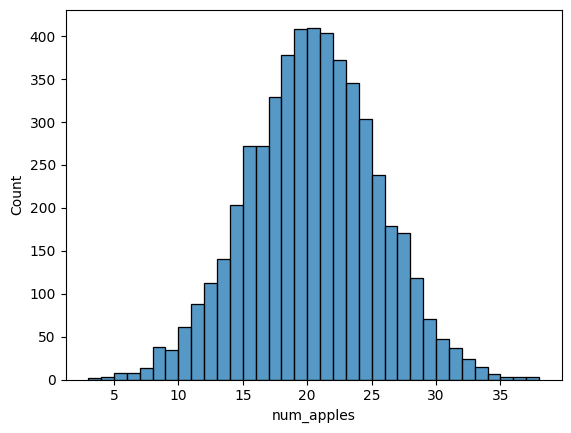

In [25]:
## Calculate bin edges using a specific rule by setting the 'bins' parameter
## Other options 'sturges', 'sqrt', and more.
my_hist = sns.histplot(data=spend_n_save_df, x='num_apples', bins='scott')

Now, because the histogram looks like a jagged normal-dist, we'll try to fit a norm-dist to it. That mwans we need to calculate the mean and SD of the data. Specifically, we have all of the measurements of the entire populaiton, so we need to calculate the 'population mean'.

In [26]:
## Calculate the mean of the number of apples for sale
## because we are using the data from every single store
## we are calculating the Population Mean
## Anyway, we'll save the value in a var called pop_mean
pop_mean = statistics.mean(spend_n_save_df.num_apples)
pop_mean

## Then, we calculate the Population SD, and save it in a var called pop_sd
pop_sd = statistics.pstdev(spend_n_save_df.num_apples)
pop_sd

5.038359554122998

**NOTE:** If we did not have all the values of the entire Population, we would just use the estimated mean and the estimated SD.

Now that we have the mean and SD, we also need to determine the range of x-axis values for the norm-dist span.

In [27]:
## Extract min and max values for range, span
min_val = spend_n_save_df['num_apples'].min()
max_val = spend_n_save_df['num_apples'].max()

min_val
max_val

np.int64(38)

In [29]:
## Taking everything together
x_axis = np.arange(start=min_val,
                    stop=max_val,
                    step=0.1)
x_axis[:10]

array([3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9])

In [30]:
y_axis = norm.pdf(x=x_axis,
                  loc=pop_mean,
                  scale=pop_sd)
y_axis[:10]

array([0.00028106, 0.00030037, 0.00032089, 0.00034267, 0.00036579,
       0.00039032, 0.00041632, 0.00044388, 0.00047308, 0.00050401])

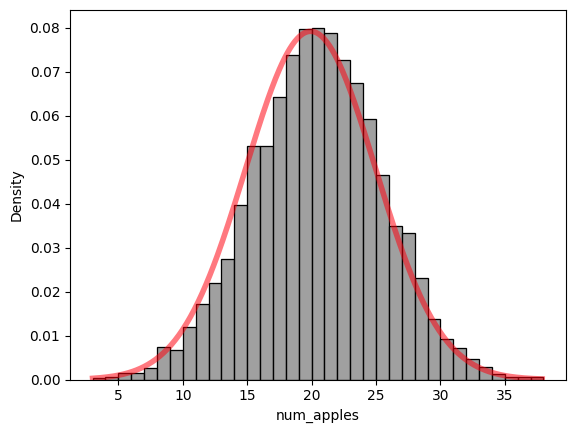

In [41]:
## First draw the histogram
## NOTE: This time, we'll set stat='density' so that the columns
# represent the density of the values – rather than the frequency. 
# This will ensure the columns are on the same scale as the density
# function we use to draw the norm-dist.
my_hist = sns.histplot(data=spend_n_save_df,
                       x='num_apples',
                       bins='scott',
                       stat='density',
                       color='grey')

# alpha in hexadecimal color code set to 88 for semi-transparency
my_hist.plot(x_axis, y_axis,
             color="#FF000D87",
             linewidth = 4)

Now that we know how to fit a statistical dist to a histogram, let´s learn how to calculate prob with stat-dist.

## Calculating probabilities with statistical distributions

If we want to calculate probabilities from a norm-dist, we use the norm.cdf() function, which returns the area under a normal curve from negative infinity to a user-specified x-axist coordinate. **cdf** stands for **cumulative distribution function** and reflect that the fact that for any x-axist coordinate, norm.cdf returns the probability of anyhting happening to the left of it. 

For example, if we wanted to use the distribution that we just fit for the `spend.n.save.df$num.apples`histogram to calculate the probability of walking into a store with 10 or fewer apples for sale, we could call `norm.cdf()` and set `x=10`, where **x** is the x-axis coordinate we are interested in, and we would set `loc=pop.mean` and `scale=pop.sd`.

In [42]:
norm.cdf(x=10, loc=pop_mean, scale=pop_sd)

np.float64(0.024447364067903828)

The result tells us there is a 10% chance that we could walk into a random store and see, at most, 10 apples for sale. 

In [43]:
norm.cdf(x=15, loc=pop_mean, scale=pop_sd)

np.float64(0.16425437997916242)

In [44]:
norm.cdf(x=30, loc=pop_mean, scale=pop_sd)

np.float64(0.9772518927973693)

## Bonus! Generating random numbers from statistical distr.

In order to generate rand-num from a norm-dist, use `norm.rvs()`, with rvs standing for random variables. Now, instead of specifying x-coordinates, we specify the number of rand-values we want.

In [49]:
np.random.seed(42) # first, set the seed so that the results are reproduceable.

## now generate 5 random values from the
## normal distribution fit to the histogram
rand_values = norm.rvs(size=5, loc=pop_mean, scale=pop_sd)

## print out the random values
rand_values

array([22.42571644, 19.22646668, 23.18637967, 27.59666397, 18.74334305])

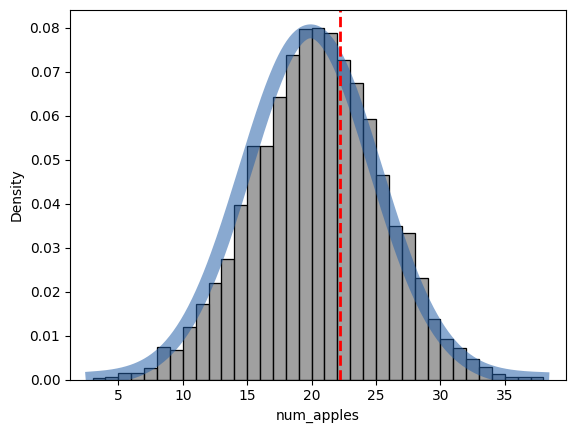

In [50]:
## First draw the histogram
my_hist = sns.histplot(data=spend_n_save_df,
                       x='num_apples',
                       bins='scott',
                       stat='density',
                       color='grey')

## Now draw the norml curve
my_hist.plot(x_axis, y_axis,
             color='#225ea888',
             linewidth=10)

## now draw a vertical line at the estimated mean
my_hist.axvline(x=est_mean, color='red', linestyle='--', linewidth=2)